# ECF 4: Pipeline NLP complet — TF-IDF · TensorFlow · FastAPI

## Partie 1 — Chargement et exploration

### 1.1 Chargement et constitution du corpus de titres

Écrivez une fonction `load_titles(filepath: str) -> pd.DataFrame` qui :

- Charge le fichier CSV
- Sélectionne et renomme les colonnes utiles : `title` → `text`, `label` → `label`
- Convertit les labels textuels en entiers : `REAL` → 1, `FAKE` → 0
- Supprime les lignes dont le titre est vide ou nul
- Affiche un résumé : nombre de titres par classe, proportion, longueur moyenne

Sauvegardez le DataFrame résultant dans `data/titles_clean.csv`.

In [58]:
import pandas as pd 
from pathlib import Path

def load_titles(filepath: str) -> pd.DataFrame:
    """
        Charge le dataset de fake news, conserve uniquement les titres,
        convertit les labels en entiers et affiche un résumé du corpus.

        Params
        ----------
        filepath : str
            Path to the CSV source file path.

        Return
        ------
        pd.DataFrame
            Clean DataFrame with 2 columns :
            - text : title of the article
            - label : 1 -> REAL, 0 -> FAKE
    """
    # Chargement
    df = pd.read_csv(filepath)

    # Vérification des colonnes attendues
    required_cols = {"title", "label"}
    missing_cols = required_cols - set(df.columns)
    if missing_cols:
        raise ValueError(f"Colonnes manquantes dans le fichier : {missing_cols}")

    # Sélection et renommage
    df = df[["title", "label"]].rename(columns={"title": "text"})

    # Suppression des titres nuls
    df = df.dropna(subset=["text"])

    # Nettoyage des espaces
    df["text"] = df["text"].astype(str).str.strip()

    # Suppression des titres vides
    df = df[df["text"] != ""]

    # Conversion des labels
    label_map = {"REAL": 1, "FAKE": 0}
    df["label"] = df["label"].map(label_map)

    # Suppression des lignes avec label inconnu
    df = df.dropna(subset=["label"])

    # Conversion finale en int
    df["label"] = df["label"].astype(int)

    # Calculs de résumé
    class_counts = df["label"].value_counts().sort_index()
    class_names = {0: "FAKE", 1: "REAL"}
    proportions = df["label"].value_counts(normalize=True).sort_index() * 100
    avg_length = df["text"].str.len().mean()

    print("\n=== Résumé ===")
    print(f"Nombre total de titres : {len(df)}")
    print(f"Longueur moyenne des titres : {avg_length:.2f} caractères\n")

    for label_value in class_counts.index:
        print(
            f"{class_names[label_value]} ({label_value}) : "
            f"{class_counts[label_value]} titres "
            f"({proportions[label_value]:.2f} %)"
        )

    return df

df_titles = load_titles("../data/fake_or_real_news.csv")

Path("data").mkdir(parents=True, exist_ok=True)
df_titles.to_csv("../data/titles_clean.csv", index=False, encoding="utf-8")

df_titles.head()


=== Résumé ===
Nombre total de titres : 6335
Longueur moyenne des titres : 65.28 caractères

FAKE (0) : 3164 titres (49.94 %)
REAL (1) : 3171 titres (50.06 %)


,text,label
0,You Can Smell Hillary’s Fear,0
1,Watch The Exact Moment Paul Ryan Committed Pol...,0
2,Kerry to go to Paris in gesture of sympathy,1
3,Bernie supporters on Twitter erupt in anger ag...,0
4,The Battle of New York: Why This Primary Matters,1


In [59]:
# Vérification
print(df_titles.info())
print(df_titles.sample(5))
print(df_titles["label"].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 6335 entries, 0 to 6334
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    6335 non-null   str  
 1   label   6335 non-null   int64
dtypes: int64(1), str(1)
memory usage: 99.1 KB
None
                                                   text  label
5846            Letter to Judge in Bundy Case in Oregon      0
4555     Networks Continue to Ignore Obamacare Collapse      0
2627             Belgian Terrorists Had Police Uniforms      1
5670  What do voters see in Trump? His authentic pho...      1
1228  Did You Notice Anything Different In The MSM L...      0
label
1    3171
0    3164
Name: count, dtype: int64


### 1.2 Analyse exploratoire

Réalisez les analyses suivantes et commentez chaque résultat dans une cellule Markdown :

- Distribution des classes : le corpus est-il équilibré ? Si non, quelle stratégie envisagez-vous ?

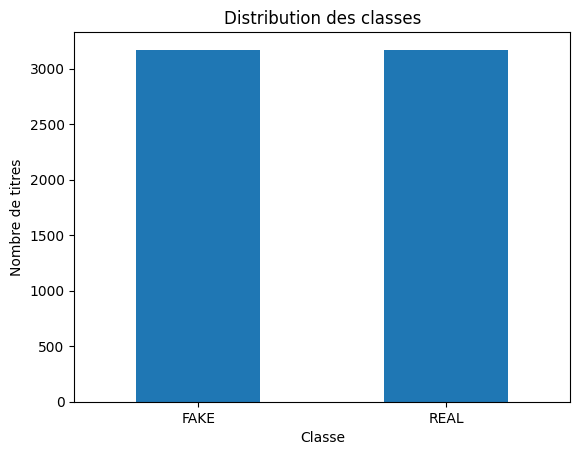

label
1    3171
0    3164
Name: count, dtype: int64
label
1    0.500552
0    0.499448
Name: count, dtype: float64


In [60]:
import matplotlib.pyplot as plt

class_counts = df_titles["label"].value_counts()

plt.figure()
class_counts.plot(kind="bar")
plt.xticks([0, 1], ["FAKE", "REAL"], rotation=0)
plt.title("Distribution des classes")
plt.xlabel("Classe")
plt.ylabel("Nombre de titres")
plt.show()

print(class_counts)
print(class_counts / len(df_titles))

Le dataset est globalement équilibré

- Distribution de la longueur des titres en tokens : histogramme par classe, valeurs min / max / médiane

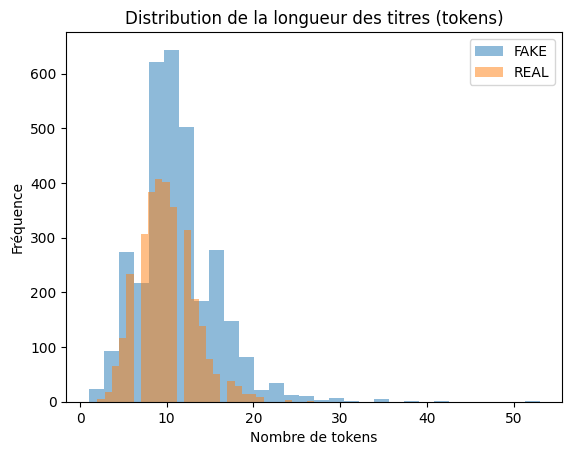

       min  max  median
label                  
0        1   53    11.0
1        2   27    10.0


In [61]:
# Tokenisation simple
df_titles["token_count"] = df_titles["text"].apply(lambda x: len(x.split()))

# Histogramme
plt.figure()
for label, name in zip([0, 1], ["FAKE", "REAL"]):
    subset = df_titles[df_titles["label"] == label]
    plt.hist(subset["token_count"], bins=30, alpha=0.5, label=name)

plt.title("Distribution de la longueur des titres (tokens)")
plt.xlabel("Nombre de tokens")
plt.ylabel("Fréquence")
plt.legend()
plt.show()

# Statistiques
stats = df_titles.groupby("label")["token_count"].agg(["min", "max", "median"])
print(stats)

L’analyse de la longueur des titres en nombre de tokens montre que :

Les titres FAKE (0) varient entre 1 et 53 tokens, avec une médiane de 11
Les titres REAL (1) varient entre 2 et 27 tokens, avec une médiane de 10

On observe que les distributions sont globalement similaires en termes de médiane.

Cependant, les titres FAKE présentent une variabilité beaucoup plus élevée, avec des titres pouvant être très longs.

Cela peut s’expliquer par le fait que les contenus trompeurs utilisent parfois des titres plus longs pour :

- attirer l’attention (clickbait)
- ajouter du sensationnel ou du contexte artificiel

À l’inverse, les titres REAL sont plus homogènes et concis, ce qui correspond à un style journalistique plus standardisé.

Cette différence de dispersion peut être exploitée indirectement par le modèle, mais elle ne constitue pas à elle seule un critère suffisant de classification.

- Top 20 des tokens les plus fréquents dans chaque classe — affichez deux diagrammes en barres côte à côte

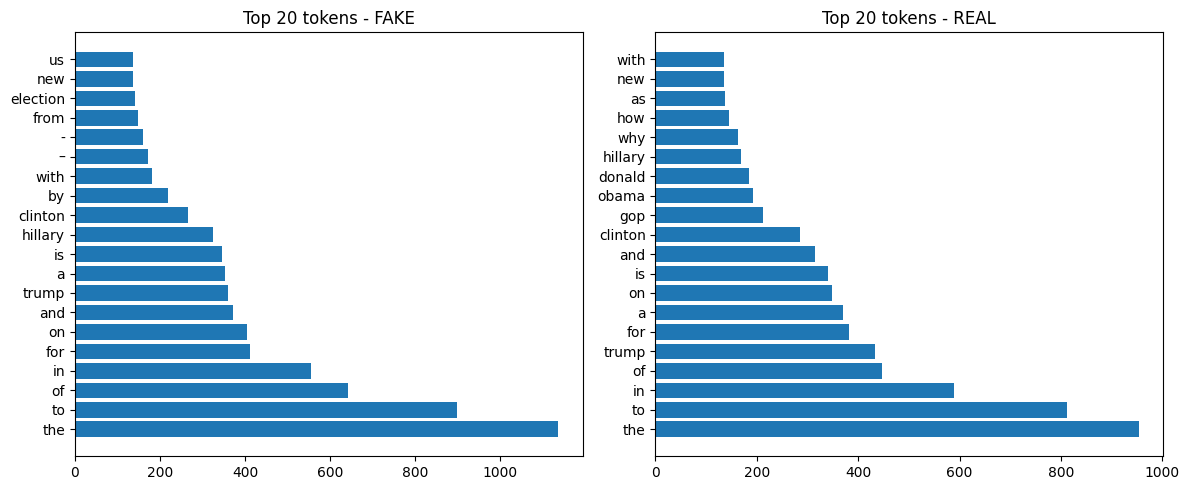

In [62]:
from collections import Counter

def get_top_tokens(texts, n=20):
    tokens = " ".join(texts).lower().split()
    return Counter(tokens).most_common(n)

fake_tokens = get_top_tokens(df_titles[df_titles["label"] == 0]["text"])
real_tokens = get_top_tokens(df_titles[df_titles["label"] == 1]["text"])

# Séparation
fake_words, fake_counts = zip(*fake_tokens)
real_words, real_counts = zip(*real_tokens)

# Plot côte à côte
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].barh(fake_words, fake_counts)
axes[0].set_title("Top 20 tokens - FAKE")

axes[1].barh(real_words, real_counts)
axes[1].set_title("Top 20 tokens - REAL")

plt.tight_layout()
plt.show()

Il y a beaucoup de mots dans ces deux groupes : l'utilisation de TF-IDF pour réduire l’impact des mots trop fréquents est justifiée.

- Identification des tokens présents dans une seule classe (discriminants purs) : listez les 10 premiers par classe

In [63]:
fake_vocab = set(" ".join(df_titles[df_titles["label"] == 0]["text"]).lower().split())
real_vocab = set(" ".join(df_titles[df_titles["label"] == 1]["text"]).lower().split())

fake_only = fake_vocab - real_vocab
real_only = real_vocab - fake_vocab

print("Top 10 tokens uniquement FAKE :", list(fake_only)[:10])
print("Top 10 tokens uniquement REAL :", list(real_only)[:10])

Top 10 tokens uniquement FAKE : ['“trump', 'freeloaders', 'university,', 'drugs?', '“work', 'carey', 'hillary?', 'journalists,', 'disorder:', 'honors']
Top 10 tokens uniquement REAL : ['conversations’', 'halt', 'charleston:', 'ag.', 'indiana:', 'roadblock', 'walls.”', 'annotated', 'hospital;', 'teams']


- Identifiez au moins 3 titres potentiellement ambigus (ni clairement fiables, ni clairement trompeurs) et expliquez pourquoi ils posent problème

In [64]:
df_titles.sample(20)[["text", "label"]]

,text,label
5835,"In rush to reclaim Yemen, exiled leaders risk ...",1
5493,Saudi Arabia poised to be reelected to UN Huma...,0
5847,Koch-backed network aims to spend nearly $1 bi...,1
5454,WE TOLD HER! Budweiser Hits “DELETE” On Beer A...,0
1257,John Oliver’s Smear Tactics Exposed As Establi...,0
3724,Trump triumphs: Two big takeaways after The Do...,1
1927,Inside Marco’s Hollow Campaign,1
888,Cop Versus Two Informed Teens who Refuse to Su...,0
1742,Hillary Clinton shatters $100M fundraising goal,1
1731,Why Everyone on Facebook Is Checking into Stan...,0


Parmis ces 20 exemples, nous pouvons choisir ces 3 titres ambigus : 

- "The Walter Scott outrage nobody is talking about" : Ce titre utilise un ton émotionnel ("outrage", "nobody is talking about") souvent associé aux fake news. Le modèle risque de le classer FAKE alors qu’il est REAL.

- "The Modern History of ‘Rigged’ US Elections" : Ce titre peut être perçu comme une analyse historique légitime ou comme une simple théorie. Le modèle peut avoir du mal à distinguer l'analyse critique du contenu trompeur.

- "Gambling on the Unknowable Trump" : Ce titre est ambigu car il reste très vague et interprétatif. Le modèle peut donc hésiter car ce type de formulation existe dans les deux classes.

## Partie 2 — Nettoyage et prétraitement

### 2.1 Pipeline de nettoyage

Implémentez une fonction `clean_title(text: str) -> str` qui applique les traitements suivants dans l'ordre :

1. Mise en minuscules
2. Suppression des URLs et des mentions de type `@username`
3. Suppression de la ponctuation et des chiffres isolés
4. Expansion des contractions anglaises (`don't` → `do not`, `isn't` → `is not`, etc.) — implémentez un dictionnaire d'au moins 20 contractions courantes
5. Suppression des stopwords anglais (NLTK) **à l'exception** des mots de négation (`not`, `no`, `never`, `neither`) — justifiez ce choix dans une cellule Markdown
6. Lemmatisation avec spaCy (modèle `en_core_web_sm`)
7. Suppression des tokens de longueur inférieure à 2 caractères après lemmatisation

Appliquez cette fonction à l'ensemble du corpus et stockez le résultat dans une colonne `text_clean`.

In [65]:
import re
import string
import pandas as pd
import nltk
import spacy
from nltk.corpus import stopwords

# Téléchargements NLTK
nltk.download("stopwords")

# Chargement du modèle spaCy
nlp = spacy.load("en_core_web_sm")

CONTRACTIONS = {
    "don't": "do not",
    "isn't": "is not",
    "doesn't": "does not",
    "didn't": "did not",
    "can't": "can not",
    "couldn't": "could not",
    "won't": "will not",
    "wouldn't": "would not",
    "shouldn't": "should not",
    "aren't": "are not",
    "wasn't": "was not",
    "weren't": "were not",
    "haven't": "have not",
    "hasn't": "has not",
    "hadn't": "had not",
    "i'm": "i am",
    "it's": "it is",
    "he's": "he is",
    "she's": "she is",
    "that's": "that is",
    "there's": "there is",
    "what's": "what is",
    "who's": "who is",
    "we're": "we are",
    "they're": "they are",
    "i've": "i have",
    "we've": "we have",
    "they've": "they have",
    "i'll": "i will",
    "we'll": "we will",
    "they'll": "they will",
    "you're": "you are",
    "you've": "you have",
    "you'll": "you will",
    "mustn't": "must not",
    "needn't": "need not"
}

stop_words = set(stopwords.words("english")) - {"not", "no", "never", "neither"}


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Administrateur\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


#### Justification de la conservation des mots de négation

Les mots de négation comme not, no, never et neither sont conservés lors de la suppression des stopwords, car ils portent une information sémantique essentielle.

En effet, la négation peut modifier fortement le sens d’une phrase. Par exemple :

"He is guilty" et
"He is not guilty"

Si le mot not est supprimé, le sens de la phrase devient incorrect, ce qui peut induire le modèle en erreur.

La conservation de ces termes permet donc de préserver des signaux importants pour la détection de désinformation.

In [66]:
def expand_contractions(text: str, contractions_dict: dict) -> str:
    """
    Remplace les contractions anglaises par leur forme développée.
    """
    pattern = re.compile(r"\b(" + "|".join(map(re.escape, contractions_dict.keys())) + r")\b")
    return pattern.sub(lambda x: contractions_dict[x.group()], text)

def clean_title(text: str) -> str:
    """
    Clean a title according to this pattern :
    1. minuscules
    2. suppression URLs et mentions @
    3. suppression ponctuation et chiffres isolés
    4. expansion des contractions
    5. suppression stopwords sauf négations
    6. lemmatisation spaCy
    7. suppression tokens < 2 caractères
    """
    if pd.isna(text):
        return ""

    # Conversion en chaîne
    text = str(text)

    # 1. Mise en minuscules
    text = text.lower()

    # 2. Suppression des URLs
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    # 2. Suppression des mentions @username
    text = re.sub(r"@\w+", " ", text)

    # 4. Expansion des contractions
    text = expand_contractions(text, CONTRACTIONS)

    # 3. Suppression de la ponctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # 3. Suppression des chiffres isolés
    text = re.sub(r"\b\d+\b", " ", text)

    # Réduction des espaces multiples
    text = re.sub(r"\s+", " ", text).strip()

    # 6. Lemmatisation avec spaCy
    doc = nlp(text)

    cleaned_tokens = []
    for token in doc:
        lemma = token.lemma_.strip()

        # ignorer espaces vides
        if not lemma:
            continue

        # 5. suppression stopwords sauf négations conservées
        if lemma in stop_words:
            continue

        # suppression tokens non alphabétiques si besoin
        if not re.match(r"^[a-zA-Z]+$", lemma):
            continue

        # 7. suppression tokens de longueur < 2
        if len(lemma) < 2:
            continue

        cleaned_tokens.append(lemma)

    return " ".join(cleaned_tokens)

df_titles["text_clean"] = df_titles["text"].apply(clean_title)
df_titles[["text", "text_clean"]].head()

,text,text_clean
0,You Can Smell Hillary’s Fear,smell hillary fear
1,Watch The Exact Moment Paul Ryan Committed Pol...,watch exact moment paul ryan commit political ...
2,Kerry to go to Paris in gesture of sympathy,kerry go paris gesture sympathy
3,Bernie supporters on Twitter erupt in anger ag...,bernie supporter twitter erupt anger dnc try warn
4,The Battle of New York: Why This Primary Matters,battle new york primary matter


### 2.2 Mesure de l'impact du nettoyage

Calculez et affichez :

- La taille du vocabulaire avant et après nettoyage

In [67]:
# Vocabulaire AVANT nettoyage
vocab_before = set(" ".join(df_titles["text"].str.lower()).split())

# Vocabulaire APRÈS nettoyage
vocab_after = set(" ".join(df_titles["text_clean"]).split())

print(f"Taille vocabulaire AVANT : {len(vocab_before)}")
print(f"Taille vocabulaire APRÈS : {len(vocab_after)}")
print(f"Réduction : {len(vocab_before) - len(vocab_after)}")

Taille vocabulaire AVANT : 14454
Taille vocabulaire APRÈS : 8011
Réduction : 6443


Le nettoyage permet de réduire significativement la taille du vocabulaire (on passe de 14454 à 8011).

Cette réduction s’explique par :

- la suppression des stopwords
- la lemmatisation (regroupement des variantes d’un mot)
- la suppression de la ponctuation et des tokens inutiles

Cela permet de :

- diminuer la dimension des vecteurs TF-IDF
- améliorer la généralisation du modèle
- réduire le bruit

- La réduction moyenne de la longueur des titres (en tokens)

In [68]:
df_titles["len_before"] = df_titles["text"].apply(lambda x: len(x.split()))
df_titles["len_after"] = df_titles["text_clean"].apply(lambda x: len(x.split()))

reduction = (df_titles["len_before"] - df_titles["len_after"]).mean()

print("Longueur moyenne avant :", df_titles["len_before"].mean())
print("Longueur moyenne après :", df_titles["len_after"].mean())
print("Réduction moyenne :", reduction)

Longueur moyenne avant : 10.496448303078138
Longueur moyenne après : 7.279400157853196
Réduction moyenne : 3.2170481452249406


Le nettoyage réduit la longueur moyenne des titres (on passe de 10 à 7 environ).

Cette réduction provient principalement de :

- la suppression des mots peu informatifs (stopwords)
- l’élimination des éléments inutiles (ponctuation, chiffres)

Le texte devient plus dense en information, ce qui est bénéfique pour les modèles NLP.

- Le nombre de titres devenus vides après nettoyage : comment les gérez-vous ?

In [69]:
empty_titles = df_titles[df_titles["text_clean"].str.strip() == ""]

print("Nombre de titres vides :", len(empty_titles))

# tritres originaux concernés:
empty_titles[["text"]].head(20)

Nombre de titres vides : 3


,text
3235,What Is To Be Done?
3456,:
6037,C праздником ребята и спасибо вам!


Certains titres deviennent vides après nettoyage (ici, il y en a 3).

Il existe plusieurs stratégies possibles :

- Les garder : ce qui entrainerait du bruit inutile
- Les supprimer : solution choisie
- Les remplacer par un token spécial (<empty>)

Ici, nous choisissons de supprimer ces titres car ils ne contiennent aucune information exploitable.

In [70]:
# suppression des titres vides 
df_titles = df_titles[df_titles["text_clean"].str.strip() != ""]

**Question écrite :** Pourquoi la conservation des mots de négation est-elle particulièrement importante dans un contexte de détection de désinformation ? Donnez deux exemples concrets tirés du corpus.

La conservation des mots de négation (comme not, no, never) est essentielle car ils modifient profondément le sens d’un titre.

En effet, supprimer ces mots peut entraîner une interprétation incorrecte, ce qui impacte directement la qualité du modèle de classification.

Nous pouvons prendre ces 2 exemples tirés de notre corpus : 

- "How Ryan decided to ditch Trump" et "How Ryan decided not to ditch Trump" expriment des idées opposées.

- "The Trump Recession: He’s linked himself to [...]"  et "The Trump Recession: He’s not linked himself to [...]" expriment des idées opposées.

La suppression de not inverse complètement le sens du titre.

La négation constitue donc un signal sémantique critique, particulièrement dans un contexte de détection de désinformation où les nuances de sens sont essentielles.

Sa conservation permet donc d’éviter des erreurs graves de classification.

## Partie 3 — Représentation vectorielle

### 3.1 Vectorisation TF-IDF

Transformez les titres nettoyés en vecteurs numériques avec `TfidfVectorizer` de scikit-learn.

- Découpez le corpus en train (80 %) et test (20 %) avec stratification sur les labels et `random_state=42`

In [71]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib
import os

X = df_titles["text_clean"]
y = df_titles["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train size :", X_train.shape[0])
print("Test size :", X_test.shape[0])

Train size : 5065
Test size : 1267


Le découpage du dataset est réalisé avec une stratification sur les labels afin de conserver la même proportion de classes dans les ensembles d’entraînement et de test.

Cela permet d’éviter un biais dans l’évaluation du modèle.

In [72]:
vectorizer = TfidfVectorizer(
    max_features=3000,
    min_df=2,
    max_df=0.85,
    ngram_range=(1, 2),
    sublinear_tf=True
)

Les paramètres du TF-IDF sont choisis pour optimiser la représentation :

- max_features=3000 → limite la dimension pour éviter la surcomplexité
- min_df=2 → supprime les mots trop rares (bruit)
- max_df=0.85 → supprime les mots trop fréquents (peu informatifs)
- ngram_range=(1,2) → capture les mots seuls + expressions ("fake news")
- sublinear_tf=True → réduit l’impact des mots très fréquents

Cela permet d’obtenir une représentation plus robuste et pertinente.

- Entraînez le vectoriseur **uniquement sur le train**, transformez train et test séparément

In [73]:
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

Le vectoriseur est entraîné uniquement sur les données d’entraînement afin d’éviter toute fuite de données (data leakage).

Les données de test sont uniquement transformées avec ce vectoriseur.

- Sauvegardez le vectoriseur avec `joblib`

In [74]:
#os.makedirs("models", exist_ok=True)

joblib.dump(vectorizer, "../models/vectorizer.pkl")

print("Vectorizer sauvegardé dans models/vectorizer.pkl")

Vectorizer sauvegardé dans models/vectorizer.pkl


### 3.2 Embedding avec TensorFlow

En parallèle du TF-IDF, préparez une seconde représentation basée sur des embeddings appris :

- Utilisez `tf.keras.layers.TextVectorization` pour construire un vocabulaire d'index à partir des titres bruts (non lemmatisés)
- Fixez `max_tokens=5000` et `output_sequence_length=30` (padding/truncation)
- Cette couche sera intégrée directement dans les modèles de la Partie 4

In [75]:
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization

max_tokens = 5000
sequence_length = 30

vectorize_layer = TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
    output_sequence_length=sequence_length
)

# adaptation sur le train uniquement : 

vectorize_layer.adapt(X_train.values)

# vérif

vocab = vectorize_layer.get_vocabulary()

print("Taille du vocabulaire :", len(vocab))
print("Exemple vocabulaire :", vocab[:20])

# exemple: 

example = ["Trump makes new policy announcement"]
vectorized_example = vectorize_layer(example)

print("Exemple :", vectorized_example)

Taille du vocabulaire : 5000
Exemple vocabulaire : ['', '[UNK]', np.str_('trump'), np.str_('clinton'), np.str_('hillary'), np.str_('not'), np.str_('obama'), np.str_('new'), np.str_('donald'), np.str_('gop'), np.str_('election'), np.str_('say'), np.str_('video'), np.str_('debate'), np.str_('campaign'), np.str_('email'), np.str_('america'), np.str_('win'), np.str_('us'), np.str_('state')]
Exemple : tf.Tensor(
[[  2   1   7 134 953   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0]], shape=(1, 30), dtype=int64)


La couche TextVectorization transforme les textes en séquences d’indices correspondant à un vocabulaire appris.

- Chaque mot est converti en entier.
- Les séquences sont tronquées ou paddées à une longueur fixe (30).

Cette représentation est adaptée aux modèles de deep learning qui utilisent des embeddings.

In [ ]:
embedding_model = tf.keras.Sequential([
    vectorize_layer,
    tf.keras.layers.Embedding(input_dim=max_tokens, output_dim=128),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

In [ ]:
embedding_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# Données brutes pour ce modèle embedding
X_raw = df_titles["text"]
y = df_titles["label"]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

history = embedding_model.fit(
    X_train_raw,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32
)

test_loss, test_acc = embedding_model.evaluate(X_test_raw, y_test)
print("Test accuracy :", test_acc)

**Question écrite :** Quelle différence fondamentale y a-t-il entre un vecteur TF-IDF et un vecteur d'embedding appris ? Laquelle de ces deux représentations est capable de capturer que `misleading` et `deceptive` sont sémantiquement proches ? Justifiez.

Un vecteur TF-IDF représente un texte comme un vecteur de fréquences pondérées des mots: 

- Chaque dimension correspond à un mot du vocabulaire
- Les mots sont considérés indépendamment les uns des autres
- Il n’y a aucune notion de similarité sémantique

À l’inverse, un embedding représente chaque mot sous forme d’un vecteur dense de faible dimension:

- Les mots sont projetés dans un espace vectoriel continu
- Les relations sémantiques entre mots peuvent être apprises
- Des mots proches en sens auront des vecteurs proches

La représentation capable de capturer que "misleading" et "deceptive" sont sémantiquement proches est l’***embedding***.

Dans le TF-IDF :

- "misleading" et "deceptive" sont deux dimensions totalement indépendantes
- Leur similarité n’est pas prise en compte

Dans l'embedding :

- Le modèle apprend que ces mots apparaissent dans des contextes similaires
- Leurs vecteurs deviennent proches dans l’espace vectoriel

Cela permet de mieux comprendre le langage.

Les embeddings sont donc plus adaptés pour capturer la sémantique du langage, tandis que TF-IDF est plus simple mais limité.

## Partie 4 — Modélisation

### 4.1 Modèle baseline — réseau dense sur TF-IDF

Construisez un premier modèle avec l'API Sequential de TensorFlow, prenant en entrée les vecteurs TF-IDF :

In [79]:
# préparation des matrices : 

import numpy as np

X_train_dense = X_train_tfidf.toarray()
X_test_dense = X_test_tfidf.toarray()

print("Shape X_train_dense :", X_train_dense.shape)
print("Shape X_test_dense :", X_test_dense.shape)

Shape X_train_dense : (5065, 3000)
Shape X_test_dense : (1267, 3000)


In [80]:
# construction modèle : 

import tensorflow as tf

tfidf_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_dense.shape[1],)),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

- Compilez avec `optimizer='adam'`, `loss='binary_crossentropy'`, `metrics=['accuracy']`

In [81]:
# compilation: 
tfidf_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

tfidf_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 256)            │       768,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 801,281 (3.06 MB)

 Trainable params: 801,281 (3.06 MB)

 Non-trainable params: 0 (0.00 B)

- Utilisez les callbacks suivants :
  - `EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss')`
  - `ModelCheckpoint` pour sauvegarder le meilleur modèle

In [82]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath="../models/best_model.keras",
    monitor="val_loss",
    save_best_only=True
)

- Entraînez sur 30 epochs avec `validation_split=0.15`

In [83]:
# entraînement 

history_tfidf = tfidf_model.fit(
    X_train_dense,
    y_train,
    validation_split=0.15,
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

Epoch 1/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6778 - loss: 0.5934 - val_accuracy: 0.7882 - val_loss: 0.4806
Epoch 2/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8648 - loss: 0.3219 - val_accuracy: 0.7816 - val_loss: 0.4645
Epoch 3/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9287 - loss: 0.1872 - val_accuracy: 0.7724 - val_loss: 0.5820
Epoch 4/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9668 - loss: 0.1029 - val_accuracy: 0.7711 - val_loss: 0.6617
Epoch 5/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9842 - loss: 0.0530 - val_accuracy: 0.7763 - val_loss: 0.7836
Epoch 6/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9949 - loss: 0.0240 - val_accuracy: 0.7697 - val_loss: 0.9354
Epoch 7/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9981 - loss: 0.0128 - val_accuracy: 0.7618 - val_loss: 1.0542


- Tracez les courbes de loss et d'accuracy (train vs validation)

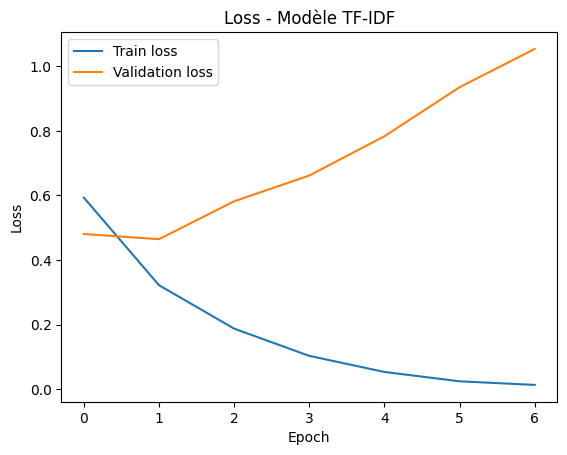

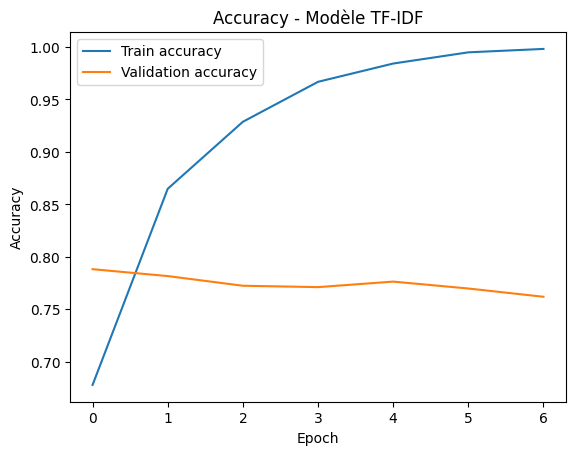

In [84]:
# Courbe de loss
plt.figure()
plt.plot(history_tfidf.history["loss"], label="Train loss")
plt.plot(history_tfidf.history["val_loss"], label="Validation loss")
plt.title("Loss - Modèle TF-IDF")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Courbe d'accuracy
plt.figure()
plt.plot(history_tfidf.history["accuracy"], label="Train accuracy")
plt.plot(history_tfidf.history["val_accuracy"], label="Validation accuracy")
plt.title("Accuracy - Modèle TF-IDF")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [85]:
# Évaluation finale
test_loss, test_accuracy = tfidf_model.evaluate(X_test_tfidf.toarray(), y_test, verbose=0)
print(f"Test loss : {test_loss:.4f}")
print(f"Test accuracy : {test_accuracy:.4f}")

Test loss : 0.4462
Test accuracy : 0.7972


Un premier modèle a été construit à partir des vecteurs TF-IDF avec un réseau dense.

L’architecture choisie permet :

- d’exploiter la représentation vectorielle sparse produite par TF-IDF.
- d’apprendre des combinaisons non linéaires de caractéristiques.
- de limiter le surapprentissage.

L’utilisation de EarlyStopping permet d’arrêter l’entraînement lorsque la performance de validation cesse de s’améliorer.
ModelCheckpoint sauvegarde automatiquement le meilleur modèle obtenu.

### 4.2 Modèle avec embeddings appris — architecture séquentielle